In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("/content/drive/MyDrive/Data Science Project Lifecycle/Individual Coursework/Agricultural land_clean.csv")

**Descriptive Statistics**

In [10]:
print("\n Descriptive Statistics (2022 snapshot — most recent complete year)")
print("-" * 65)
stats = df_2022["Agri_Land_Pct"].describe()
print(f"  Count   : {int(stats['count'])} countries")
print(f"  Mean    : {stats['mean']:.2f}%")
print(f"  Median  : {stats['50%']:.2f}%")
print(f"  Std Dev : {stats['std']:.2f}%")
print(f"  Min     : {stats['min']:.2f}%  ({df_2022.nsmallest(1,'Agri_Land_Pct')['Country'].values[0]})")
print(f"  Max     : {stats['max']:.2f}%  ({df_2022.nlargest(1,'Agri_Land_Pct')['Country'].values[0]})")

print("\n Top 10 countries by agricultural land % (2022)")
top10 = df_2022.nlargest(10, "Agri_Land_Pct")[["Country", "Agri_Land_Pct"]]
for _, row in top10.iterrows():
    print(f"  {row['Country']:<30} {row['Agri_Land_Pct']:.2f}%")

print("\n Bottom 10 countries by agricultural land % (2022)")
bot10 = df_2022.nsmallest(10, "Agri_Land_Pct")[["Country", "Agri_Land_Pct"]]
for _, row in bot10.iterrows():
    print(f"  {row['Country']:<30} {row['Agri_Land_Pct']:.2f}%")


 Descriptive Statistics (2022 snapshot — most recent complete year)
-----------------------------------------------------------------
  Count   : 219 countries
  Mean    : 37.55%
  Median  : 38.89%
  Std Dev : 22.12%
  Min     : 0.45%  (Suriname)
  Max     : 84.55%  (Turkmenistan)

 Top 10 countries by agricultural land % (2022)
  Turkmenistan                   84.55%
  Côte d’Ivoire                  84.16%
  Burundi                        82.81%
  Uruguay                        80.87%
  Saudi Arabia                   80.77%
  Rwanda                         80.04%
  South Africa                   79.42%
  Kazakhstan                     79.37%
  Nigeria                        75.97%
  Moldova                        74.97%

 Bottom 10 countries by agricultural land % (2022)
  Suriname                       0.45%
  Greenland                      0.59%
  Singapore                      0.92%
  Turks and Caicos Islands       1.05%
  Northern Mariana Islands       1.17%
  Bahamas, The       

**Global Average Trend Line**

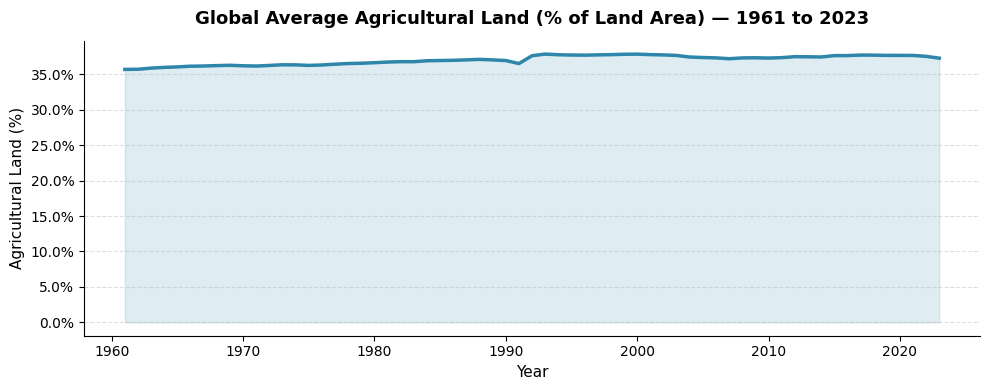

In [2]:
trend = df.groupby("Year")["Agri_Land_Pct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trend["Year"], trend["Agri_Land_Pct"], color="#2E86AB", linewidth=2.5)
ax.fill_between(trend["Year"], trend["Agri_Land_Pct"], alpha=0.15, color="#2E86AB")
ax.set_title("Global Average Agricultural Land (% of Land Area) — 1961 to 2023",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Agricultural Land (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Regional Comparison Bar Chart**

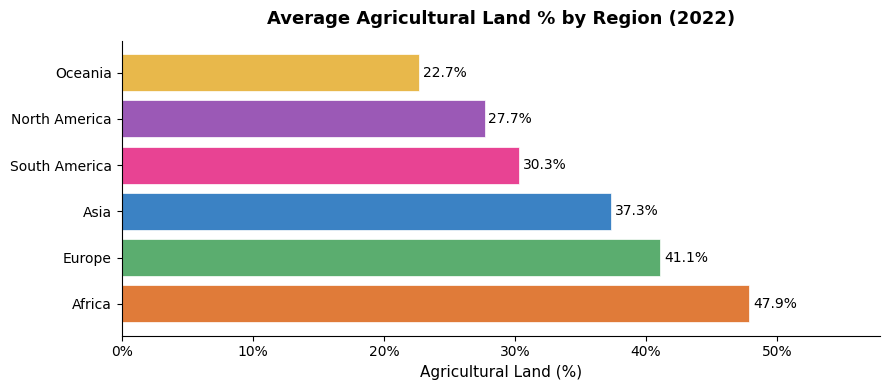

In [3]:
df_2022 = df[df["Year"] == 2022].copy()

COLORS = {
    "Africa": "#E07B39", "Asia": "#3B82C4", "Europe": "#5BAD6F",
    "North America": "#9B59B6", "South America": "#E84393", "Oceania": "#E8B84B",
}

reg_2022 = (
    df_2022[df_2022["Region"] != "Other"]
    .groupby("Region")["Agri_Land_Pct"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(reg_2022.index, reg_2022.values,
               color=[COLORS.get(r, "#95A5A6") for r in reg_2022.index],
               edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, reg_2022.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_title("Average Agricultural Land % by Region (2022)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Agricultural Land (%)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, reg_2022.max() + 10)
plt.tight_layout()
plt.show()

**Top & Bottom 10 Countries Bar Chart**

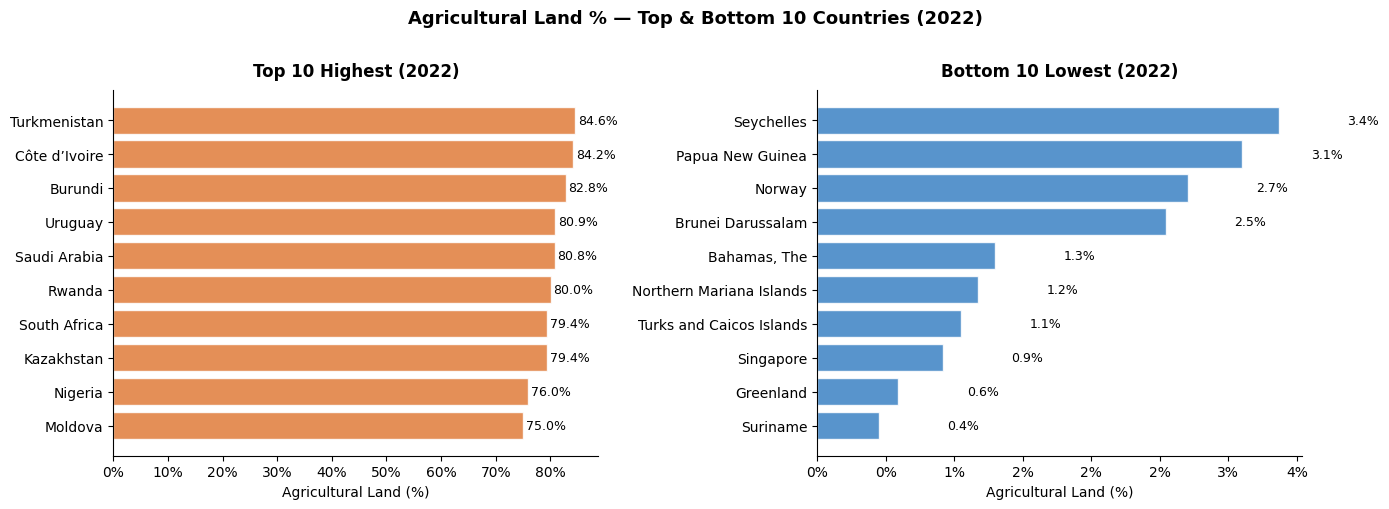

In [4]:
df_2022 = df[df["Year"] == 2022].copy()

top_n = df_2022.nlargest(10, "Agri_Land_Pct")[["Country", "Agri_Land_Pct"]].iloc[::-1]
bot_n = df_2022.nsmallest(10, "Agri_Land_Pct")[["Country", "Agri_Land_Pct"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (ax1, top_n, "Top 10 Highest (2022)", "#E07B39"),
    (ax2, bot_n, "Bottom 10 Lowest (2022)", "#3B82C4"),
]:
    bars = ax.barh(data["Country"], data["Agri_Land_Pct"],
                   color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, data["Agri_Land_Pct"]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Agricultural Land (%)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

fig.suptitle("Agricultural Land % — Top & Bottom 10 Countries (2022)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Distribution Histogram**

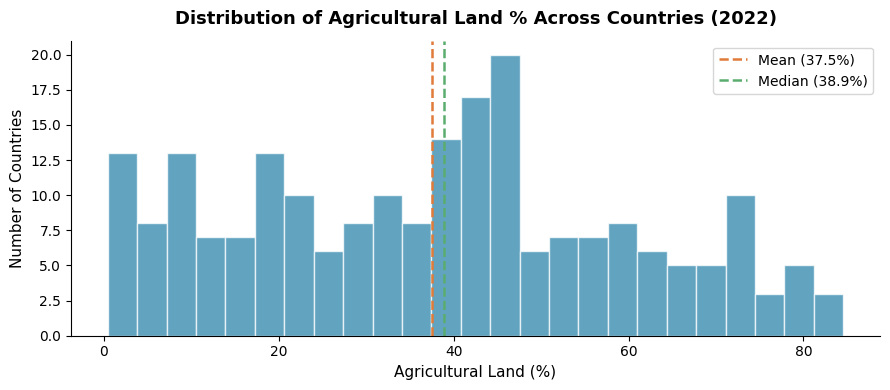

In [5]:
df_2022 = df[df["Year"] == 2022].copy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_2022["Agri_Land_Pct"], bins=25, color="#2E86AB", alpha=0.75, edgecolor="white")
ax.axvline(df_2022["Agri_Land_Pct"].mean(), color="#E07B39", linestyle="--", linewidth=1.8,
           label=f"Mean ({df_2022['Agri_Land_Pct'].mean():.1f}%)")
ax.axvline(df_2022["Agri_Land_Pct"].median(), color="#5BAD6F", linestyle="--", linewidth=1.8,
           label=f"Median ({df_2022['Agri_Land_Pct'].median():.1f}%)")
ax.set_title("Distribution of Agricultural Land % Across Countries (2022)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Agricultural Land (%)", fontsize=11)
ax.set_ylabel("Number of Countries", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Selected Country Trends (6-panel)**

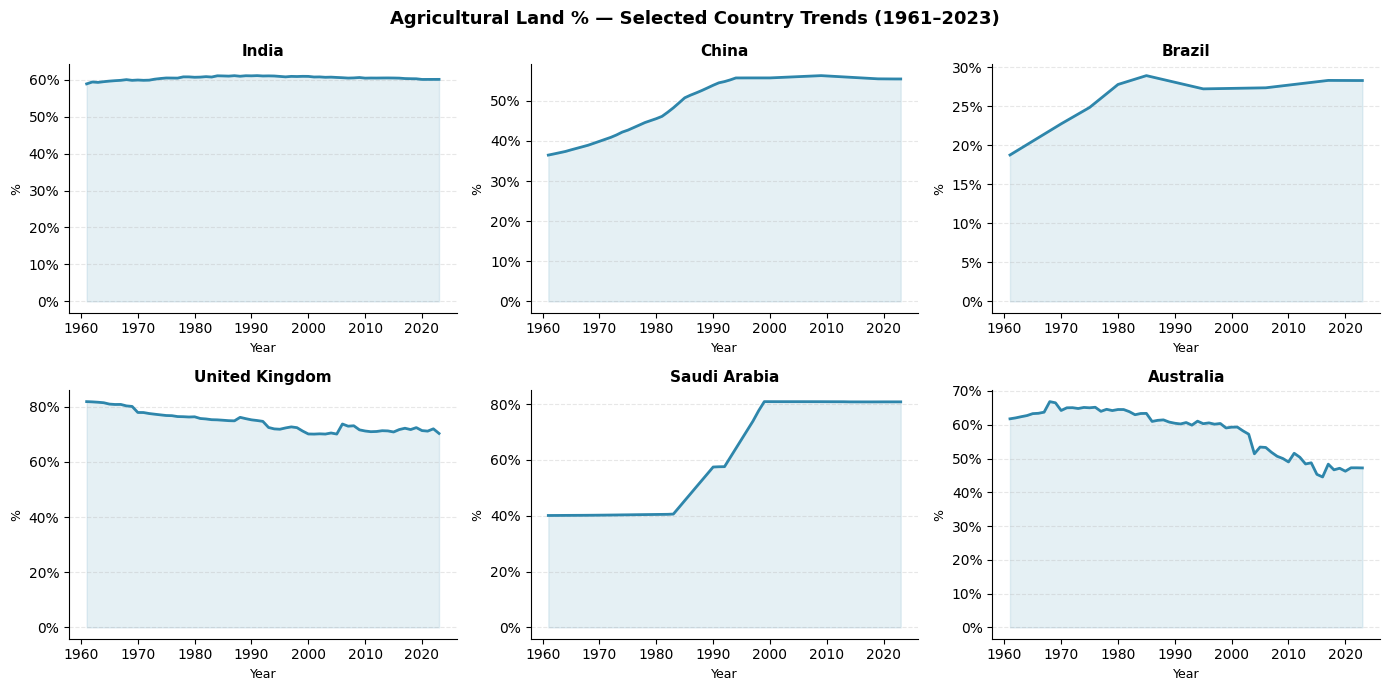

In [6]:
highlight_countries = ["India", "China", "Brazil", "United Kingdom", "Saudi Arabia", "Australia"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, country in enumerate(highlight_countries):
    cdf = df[df["Country"] == country].sort_values("Year")
    axes[i].plot(cdf["Year"], cdf["Agri_Land_Pct"], color="#2E86AB", linewidth=2)
    axes[i].fill_between(cdf["Year"], cdf["Agri_Land_Pct"], alpha=0.12, color="#2E86AB")
    axes[i].set_title(country, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Year", fontsize=9)
    axes[i].set_ylabel("%", fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Agricultural Land % — Selected Country Trends (1961–2023)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Year-on-Year Change (Top & Bottom 5 Table)**

In [7]:
df_changes = df.dropna(subset=["YoY_Change"])

top_changes = df_changes.nlargest(5, "YoY_Change")[["Country", "Year", "YoY_Change"]]
bot_changes = df_changes.nsmallest(5, "YoY_Change")[["Country", "Year", "YoY_Change"]]

print("Largest Year-on-Year INCREASES:")
print(top_changes.to_string(index=False))

print("\nLargest Year-on-Year DECREASES:")
print(bot_changes.to_string(index=False))

Largest Year-on-Year INCREASES:
               Country  Year  YoY_Change
            San Marino  2015   21.666667
   St. Kitts and Nevis  1980   14.835165
British Virgin Islands  1966   13.333333
               Burundi  1969    8.605919
           Gambia, The  2008    6.916996

Largest Year-on-Year DECREASES:
               Country  Year  YoY_Change
Bosnia and Herzegovina  2022  -22.382812
            Montenegro  2013  -21.551673
               Croatia  2000  -15.436269
               Eritrea  2004  -12.928419
   St. Kitts and Nevis  2005  -11.653846
